Цель: Научиться применять методы предобработки данных на реальном датасете, оценивать их влияние на качество модели и понимать важность каждого этапа.

Дтасет Bank Marketing Dataset

Ссылка для примера: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

Целевая переменная: deposit (будет ли клиент открывать депозит).



**Важное условие:** С самого начала разделите исходные данные на обучающую (train) и тестовую (test) выборки в соотношении 80/20. Используйте параметр random_state=42 для воспроизводимости. Все этапы предобработки (заполнение пропусков, кодирование, масштабирование, PCA) должны настраиваться/обучаться ТОЛЬКО на обучающей выборке, а затем применяться к тестовой. Это критически важно для корректной оценки. За основную модель возьмите Random Forest Classifier

1. Базовый анализ (1 балл)

- Загрузите данные, разделите на train/test

- Проведите разведочный анализ данных, посмотрите распределение целевой переменной

- Обучите модель на числовых признаках без обработки (baseline) и на тестовой выборке оцените accuracy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error

In [3]:
import kagglehub
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
import os
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(path, file), sep=';')
        print(f"Загружен файл: {file}")
        break

Using Colab cache for faster access to the 'bank-marketing' dataset.
Загружен файл: bank-additional-full.csv


In [4]:
X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [7]:
categorical_columns = [c for c in df if df[c].dtype == 'O']
numeric_columns = df.columns.drop(categorical_columns).tolist()

print(categorical_columns)
print(numeric_columns)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


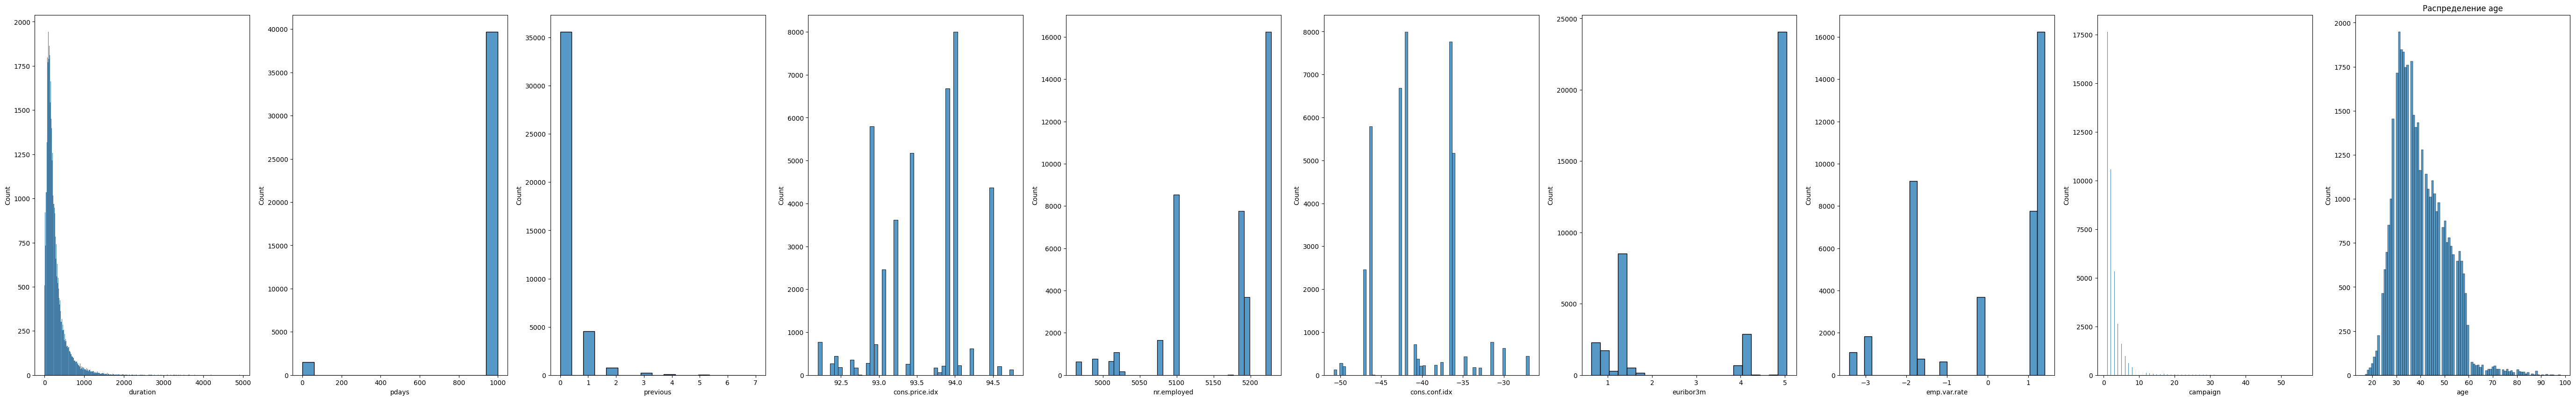

In [8]:
import seaborn as sns
def check(df):
  fig, axes = plt.subplots(1,len(numeric_columns), figsize =(70, 10))

  for i,numeric_column_name in enumerate(list(set(df.columns) - set(categorical_columns))):
    sns.histplot(df[numeric_column_name], ax=axes[i]);
    plt.title(f'Распределение {numeric_column_name}');

check(df)

Распределение классов: 

y
no     36548
yes     4640
Name: count, dtype: int64

Процентное соотношение: 

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

Пропущенные значения: 0


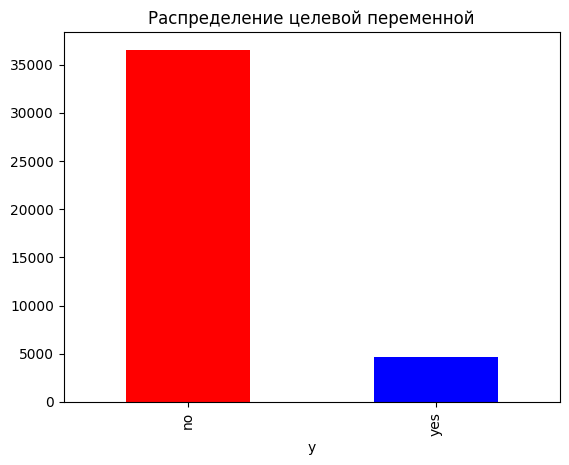

In [9]:
print("Распределение классов: \n")
print(y.value_counts())
print("\nПроцентное соотношение: \n")
print(y.value_counts(normalize=True) * 100)

print("\nПропущенные значения:", df.isnull().sum().sum())

y.value_counts().plot(kind='bar', color=['red', 'blue'])
plt.title('Распределение целевой переменной')
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

baseline = RandomForestClassifier(class_weight='balanced', n_estimators=100, n_jobs=-1)
baseline.fit(X_train_num, y_train)
y_pred_baseline = baseline.predict(X_test_num)

In [11]:
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy baseline: {accuracy_baseline:.4f}")

Accuracy baseline: 0.9153


2. Обработка пропусков (2 балла)

- Найдите и заполните пропуски в train (2 способами):
  - Удаление строк с пропусками
  - Замена пропусков на медиану (для числовых) или моду (для категориальных).

- Обучите модель на данных без пропусков и на тестовой выборке оцените accuracy

3. Кодирование категориальных признаков (2 балла)
- Используй данные полученные 2  методом и далее во всех задачах

- Примените Label Encoding и One-Hot Encoding

- Обучите модель с закодированными признаками и на тестовой выборке оцените accuracy



4. Обработка выбросов (2 балла )
- Визуализируйте выбросы с помощью boxplot для числовых признаков.

- Примените метод IQR для обнаружения и обработки выбросов .

- Обучите модель на данных без выбросов и на тестовой выборке оцените accuracy


5. Масштабирование признаков (2 балла)

- Примените StandardScaler или MinMaxScaler только к train выборке

- Обучите модель на данных с масштабированными признаками и на тестовой выборке оцените accuracy


6. Итоги (1 балл)

- Сравните модели и создайте таблицу с accuracy всех моделей.
- Сделайте выводы